# Healthcare ML Platform
## Notebook 05 — Feature Engineering: Insurance Dataset

**Input:**  `data/processed/insurance_clean.csv`  
**Output:** `data/processed/insurance_train.csv`  
           `data/processed/insurance_test.csv`  
           `models/insurance_scaler.pkl`  
           `models/insurance_encoders.pkl`  

### What this notebook does
1. Encode categorical columns (sex, smoker, region)
2. Create one interaction feature (smoker × bmi)
3. Apply log transformation to target (charges)
4. Scale numeric features
5. Split into train and test sets
6. Save everything for the regression notebook

### Why log transform charges?
Raw charges are right-skewed ($1k to $63k).  
Log transformation makes the distribution more symmetric  
which helps linear models significantly.  
XGBoost doesn't need it — but we apply it anyway  
and compare both versions in the regression notebook.

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import joblib
import os
import warnings

warnings.filterwarnings("ignore")


## Load Cleaned Data

In [70]:
df= pd.read_csv(r"G:\healthcare\Dataset\processed\insurance_clean.csv")
print(f"Shape : {df.shape}")
print(f"Columns : {list(df.columns)}")

print("\nCategorical Columns")
for col in df.select_dtypes(include="object").columns:
    print(f"{col}: {df[col].unique()}")

df.head(3)

Shape : (1337, 7)
Columns : ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Categorical Columns
sex: ['female' 'male']
smoker: ['yes' 'no']
region: ['southwest' 'southeast' 'northwest' 'northeast']


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523
2,28,male,33.00,3,no,southeast,4449.4620


---
##  Encode Categorical Columns


| Column | Values | Encoding method |
|---|---|---|
| `sex` | male/female | Binary: male=1, female=0 |
| `smoker` | yes/no | Binary: yes=1, no=0 |
| `region` | 4 values | One-hot encoding |

**Why one-hot for region?**  
Region has 4 categories with no natural order.  
Label encoding (0,1,2,3) would imply northwest > northeast  
which is meaningless. One-hot avoids this.

**Why binary for smoker and sex?**  
They only have 2 values — binary encoding is cleaner  
than one-hot for binary categories.

In [71]:

df_enc = df.copy()

#Binary Encoding - sex & smoker

df_enc['sex'] =df_enc['sex'].map({"male":1,"female":0})
df_enc['smoker']=df_enc['smoker'].map({"yes":1,"no":0})

print(f"Smoker distribution : {df_enc['smoker'].value_counts().to_dict}")
# One-hot encoding - region

df_enc = pd.get_dummies(df_enc,columns=["region"],prefix="region",drop_first=True)
print(f"New region columns : {[c for c in df_enc.columns if 'region' in c]}")
print(f"All columns : {list(df_enc.columns)}")




Smoker distribution : <bound method Series.to_dict of smoker
0    1063
1     274
Name: count, dtype: int64>
New region columns : ['region_northwest', 'region_southeast', 'region_southwest']
All columns : ['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']


In [72]:
df_enc.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


---
##  Create Interaction Feature

The single most important feature we can engineer here  
is the **smoker × BMI interaction**.

From the scatter plot in EDA we saw:
- Non-smokers: charges are relatively flat regardless of BMI
- Smokers: charges rise steeply with BMI

This means smoker and BMI don't act independently —  
they multiply each other's effect.

A linear model cannot learn this automatically.

In [73]:
# Interaction term - smoker x bmi
df_enc['smoker_bmi']=df_enc['smoker'] * df_enc['bmi']

# as cost of premium accelerate with age, it is not a linear relation,
#so we will create a age^2 column

df_enc['age_sqrd']= df_enc['age'] ** 2 #[captures accelerating cost with age]

print(f"\nShape: {df_enc.shape}")
print(f"Sample values :")
print(df_enc[['smoker','bmi','smoker_bmi']].head(6).to_string())




Shape: (1337, 11)
Sample values :
   smoker     bmi  smoker_bmi
0       1  27.900        27.9
1       0  33.770         0.0
2       0  33.000         0.0
3       0  22.705         0.0
4       0  28.880         0.0
5       0  25.740         0.0


---
## Log Transform the Target

`charges` is right-skewed — most patients pay $5k–$15k  
but a few smokers pay $50k+. This long tail hurts linear models.

Log transformation compresses the tail and makes  
the distribution more symmetric.

We create two versions of the target:
- `charges` — original scale (used for XGBoost)
- `log_charges` — log transformed (used for linear models)

We will compare both.

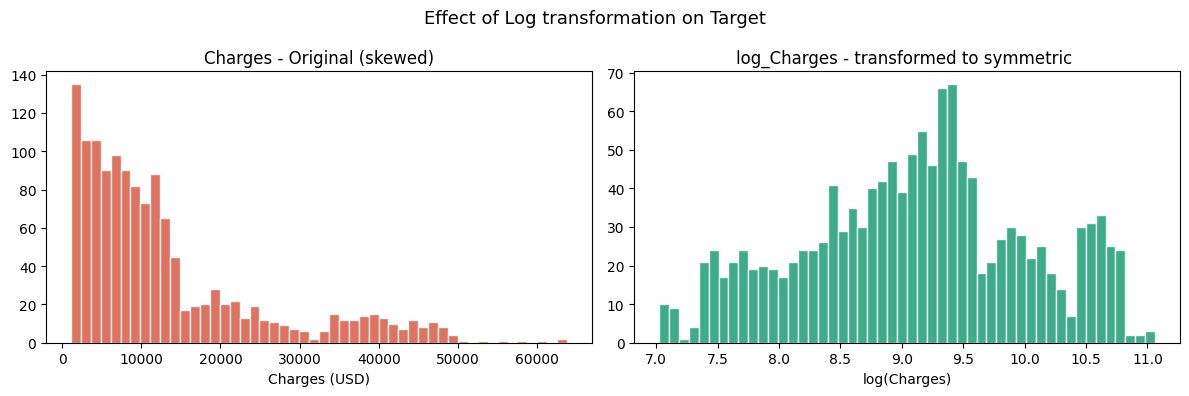

In [74]:
# log transform


from turtle import color

from pyparsing import alphanums


df_enc['log_charges'] =np.log1p(df_enc['charges'])

fig,axes = plt.subplots(1,2,figsize=(12,4))

axes[0].hist(df_enc['charges'],bins=50,color="#D85A44",edgecolor='white',alpha=0.85)
axes[0].set_title("Charges - Original (skewed)")
axes[0].set_xlabel("Charges (USD)")

axes[1].hist(df_enc['log_charges'],bins=50,color="#1D9E75",edgecolor='white',alpha=0.85)
axes[1].set_title("log_Charges - transformed to symmetric ")
axes[1].set_xlabel("log(Charges)")

plt.suptitle("Effect of Log transformation on Target",fontsize = 13)
plt.tight_layout()
plt.savefig("G:\healthcare\outputs\insurance_log_transform.png",dpi=150)
plt.show()


---
## Train/Test Split

We split before scaling — critical rule.  
Scaler must only see training data.

We create two sets of targets:
- `y_train` / `y_test` — original charges (for XGBoost)
- `y_train_log` / `y_test_log` — log charges (for linear models)

In [75]:
df_enc.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,smoker_bmi,age_sqrd,log_charges
0,19,0,27.900,0,1,16884.92400,False,False,True,27.9,361,9.734236
1,18,1,33.770,1,0,1725.55230,False,True,False,0.0,324,7.453882
2,28,1,33.000,3,0,4449.46200,False,True,False,0.0,784,8.400763
3,33,1,22.705,0,0,21984.47061,True,False,False,0.0,1089,9.998137
4,32,1,28.880,0,0,3866.85520,True,False,False,0.0,1024,8.260455


In [76]:
feature_col = [c for c in df_enc.columns if c not in ['charges','log_charges']]

X= df_enc[feature_col]
y=df_enc['charges']
y_log=df_enc['log_charges']

#split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# same split indices for log targeet
y_train_log = y_log.loc[y_train.index]
y_test_log = y_log.loc[y_test.index]

print(f"\nTrain: {X_train.shape[0]} rows")
print(f"\nTest: {X_test.shape[0]} rows")



Train: 1069 rows

Test: 268 rows


---
## Scale Features

StandardScaler normalises all numeric features  
to mean=0, std=1.


In [77]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled,columns=feature_col)
X_test_scaled = pd.DataFrame(X_test_scaled,columns=feature_col)

# save scaler
os.makedirs("G:/healthcare/models",exist_ok=True)
joblib.dump(scaler,"G:/healthcare/models/insurance_scaler.pkl")



['G:/healthcare/models/insurance_scaler.pkl']

In [78]:
#Build final train/test Dataframes
train_final = X_train_scaled.copy()
train_final["charges"] = y_train.values
train_final["log_charges"]=y_train_log.values

test_final = X_test_scaled.copy()
test_final['charges']= y_test.values
test_final['log_charges']=y_test_log.values

BASE = "G:\healthcare\Dataset\processed"
train_final.to_csv(f"{BASE}/insurance_train.csv",index=False)
test_final.to_csv(f"{BASE}/insurance_test.csv",index=False)

print(list(train_final.columns))

['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest', 'smoker_bmi', 'age_sqrd', 'charges', 'log_charges']
